In [1]:
#####

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['figure.figsize'] = (8, 6)

def show(img, title="", cmap=None, ax=None):
    """Helper to display a BGR/gray image with matplotlib."""
    
    if ax is None:
        fig, ax = plt.subplots()
    
    if cmap is None and len(img.shape) == 3:
        ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    
    else:
        ax.imshow(img, cmap=cmap or 'gray')
    
    ax.set_title(title)
    ax.axis('off')
    return ax

### 1. Load the Image

* Read the image.
* Display the original image.
* Print its width, height, and number of channels.

Width: 513
Height: 385
Channels: 3


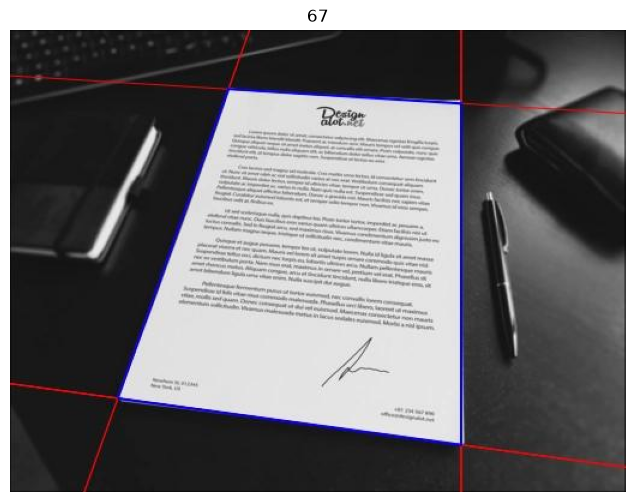

In [3]:
img_path = "Task.jpeg"

img = cv.imread(img_path)

height, width, channels = img.shape
print(f"Width: {width}")
print(f"Height: {height}")
print(f"Channels: {channels}")

show(img, "67")
plt.show()

### 2. Image Preprocessing

Improve the image quality by applying suitable preprocessing techniques such as:

* Grayscale conversion
* Noise reduction
* Image sharpening (if needed)
* Contrast enhancement

In [4]:
# BGR --> Grayscale conversion 
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Noise Reduction
denoised = cv.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)

# Contrast enhancement
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cont_enhanced = clahe.apply(denoised)

In [5]:
import numpy as np
kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])
sharpened = cv.filter2D(cont_enhanced, -1, kernel)

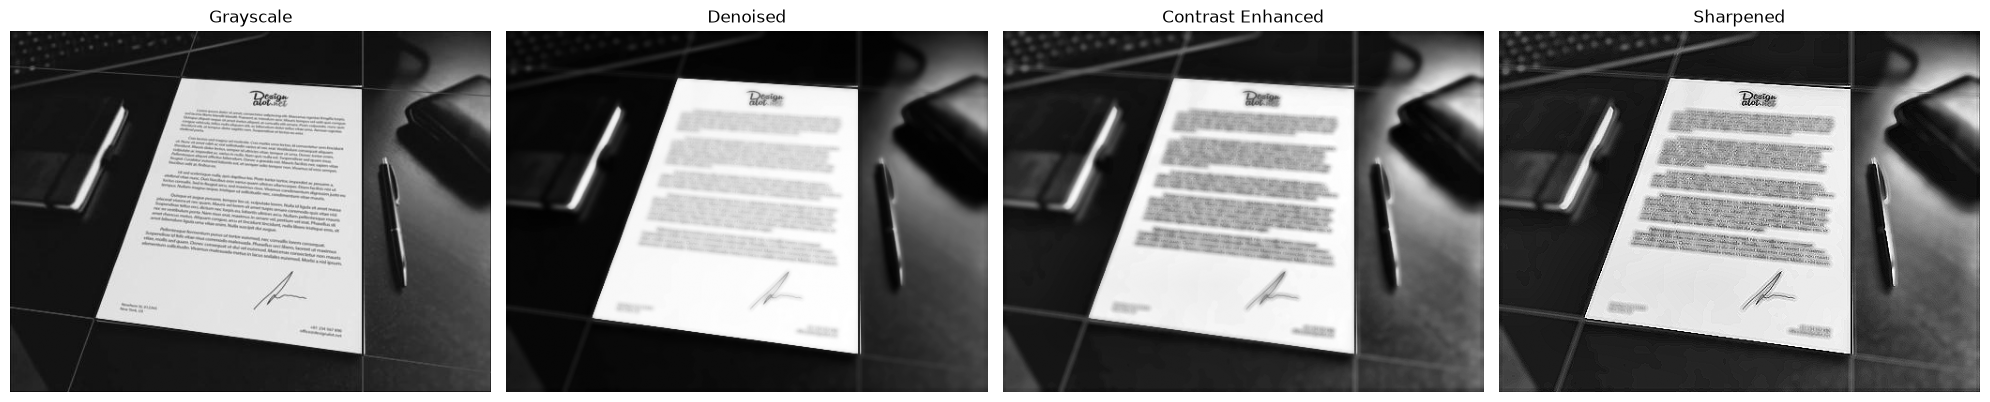

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

show(gray, "Grayscale", ax=axes[0])
show(denoised, "Denoised", ax=axes[1])
show(cont_enhanced, "Contrast Enhanced", ax=axes[2])
show(sharpened, "Sharpened", ax=axes[3])
plt.tight_layout()
plt.show()

In [7]:
preprocessed = sharpened

### 3. Edge Detection

Detect the major edges in the image using an appropriate method.

Display the detected edges.

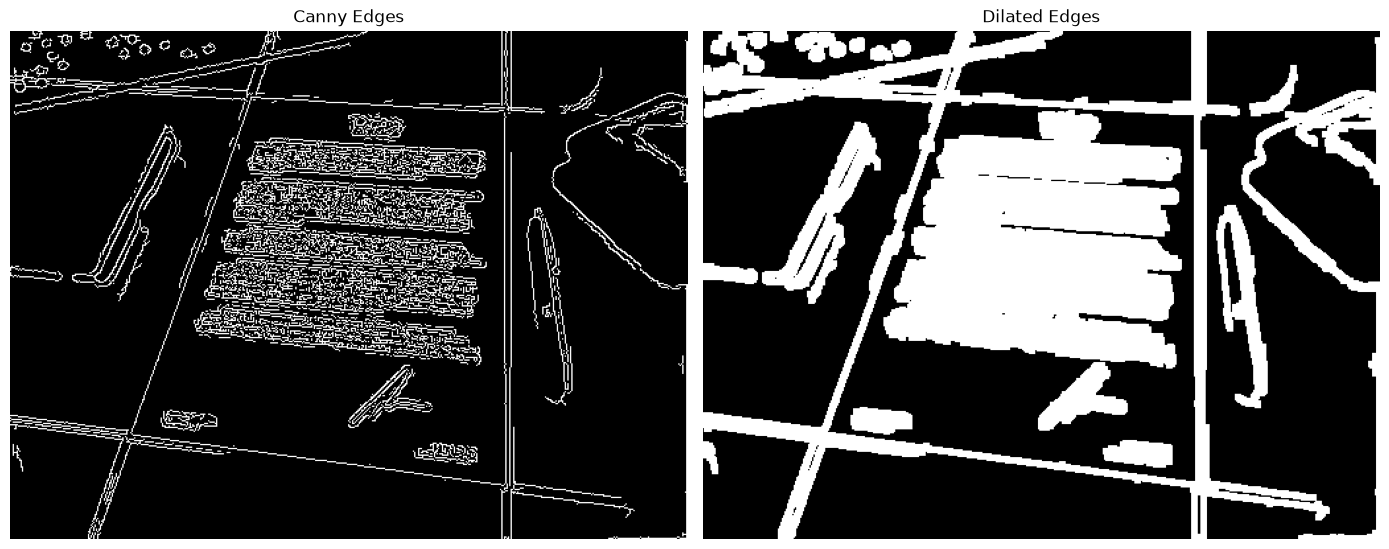

In [8]:
edges = cv.Canny(preprocessed, 50, 150)

edges_dilated = cv.dilate(edges, np.ones((5, 5), np.uint8), iterations=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

show(edges, "Canny Edges", ax=axes[0])
show(edges_dilated, "Dilated Edges", ax=axes[1])
plt.tight_layout()
plt.show()

### 4. Detect the Document

Locate the document inside the image.

Draw its contour on the original image.

In [9]:
contours, _ = cv.findContours(edges_dilated.copy(), cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv.contourArea, reverse=True)[:10]

In [ ]:
document_contour = None

for c in contours:
    peri = cv.arcLength(c, True)
    
    approx = cv.approxPolyDP(c, 0.02*peri, True)
    
    if len(approx) == 4 and cv.contourArea(c) > 0.02 * (width*height):
        document_contour = approx
        break

if document_contour is None:
    raise RuntimeError("No 4-point document contour found!")

print("Document corner points:", document_contour.reshape(4, 2))

Document corner points: [[184  54]
 [372  64]
 [372 341]
 [ 94 303]]


In [11]:
cont_area = cv.contourArea(document_contour)
perc = 100 * cv.contourArea(document_contour) / (width*height)
print(f"Document contour area: {cont_area:.0f} ({perc:.1f}% of image)")

Document contour area: 62359 (31.6% of image)


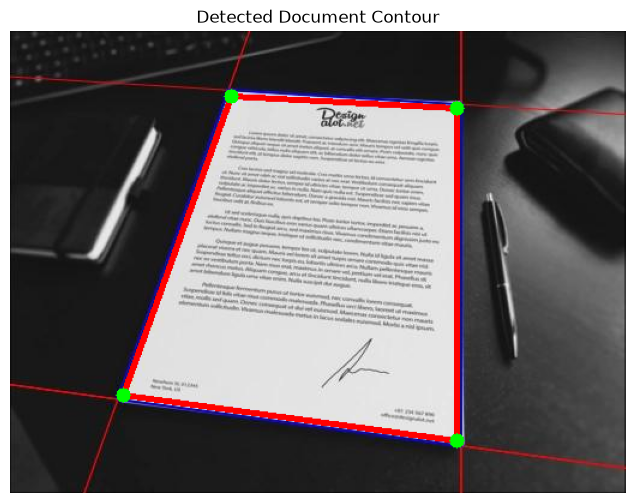

In [12]:
contour_overlay = img.copy()
cv.drawContours(contour_overlay, [document_contour], -1, (0, 0, 255), 3)

for (x, y) in document_contour.reshape(4, 2):
    cv.circle(contour_overlay, (int(x), int(y)), 6, (0, 255, 0), -1)

show(contour_overlay, "Detected Document Contour")
plt.show()

### 5. Perspective Correction

Apply a Perspective Transform to obtain a top-down scanned version of the document.

In [13]:
# first: try to order corners of the doc

def order_points(pts):
    """Order 4 points as: top-left, top-right, bottom-right, bottom-left."""
    pts = pts.reshape(4, 2).astype("float32")
    rect = np.zeros((4, 2), dtype="float32")

    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # top-left has smallest sum
    rect[2] = pts[np.argmax(s)]   # bottom-right has largest sum

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # top-right has smallest difference
    rect[3] = pts[np.argmax(diff)]  # bottom-left has largest difference
    return rect

In [14]:
# Second: try to compute the width/height from the distances between corners.
def four_point_transform(image, pts):
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    widthA = np.linalg.norm(br-bl)
    widthB = np.linalg.norm(tr-tl)
    maxWidth = int(max(widthA, widthB))

    heightA = np.linalg.norm(tr-br)
    heightB = np.linalg.norm(tl-bl)
    maxHeight = int(max(heightA, heightB))

    dst = np.array([[0, 0],
                    [maxWidth-1, 0],
                    [maxWidth-1, maxHeight-1],
                    [0, maxHeight-1]], dtype="float32")

    m = cv.getPerspectiveTransform(rect, dst)
    warped = cv.warpPerspective(image, m, (maxWidth, maxHeight))
    return warped, m

In [15]:
# Third: Build the transform matrix

warped = four_point_transform(img, document_contour)[0]
print("Warped size:", warped.shape[:2])

Warped size: (277, 280)


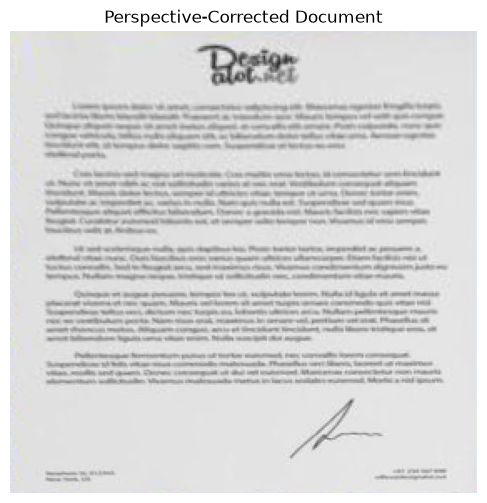

In [16]:
# put the image into the rectangle 

show(warped, "Perspective-Corrected Document")
plt.show()

### 6. Produce a Scanned Document

Generate a clean black-and-white scanned image using suitable thresholding techniques.

In [18]:
# convert the warped doc to grayscale
warped_gray = cv.cvtColor(warped, cv.COLOR_BGR2GRAY)

In [19]:
scanned = cv.adaptiveThreshold(warped_gray, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, blockSize=21, C=10)

In [20]:
# Otsu's method for comparison
_, scanned_otsu = cv.threshold(warped_gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

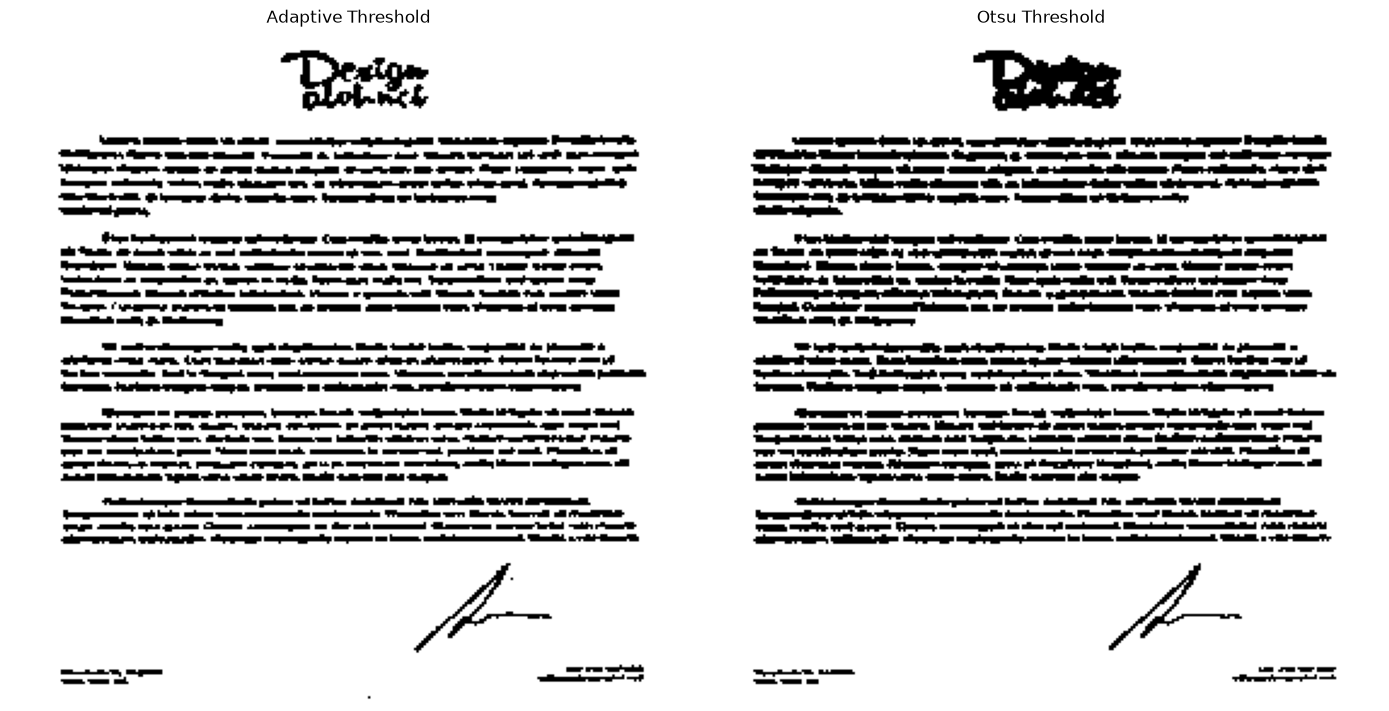

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

show(scanned, "Adaptive Threshold", ax=axes[0])
show(scanned_otsu, "Otsu Threshold", ax=axes[1])
plt.tight_layout()
plt.show()

### 7. Contour Analysis

Extract all significant contours from the processed image.

For each contour:

* Draw its bounding rectangle.
* Display its area.
* Ignore very small contours.

In [22]:
scanned_inv = cv.bitwise_not(scanned)

# Contours
all_contours, _ = cv.findContours(scanned_inv, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# ignore small contours or that contain noise
minArea = 40  
significant_contours = [c for c in all_contours if cv.contourArea(c) > minArea]
significant_contours = sorted(significant_contours, key=cv.contourArea, reverse=True)

In [23]:
contour_analysis_img = cv.cvtColor(scanned.copy(), cv.COLOR_GRAY2BGR)

print(f"Total contours found: {len(all_contours)}")
print(f"Significant contours kept: {len(significant_contours)} (area > {minArea})\n")

Total contours found: 315
Significant contours kept: 35 (area > 40)



In [24]:
for i, c in enumerate(significant_contours[:20]):  # print details for the top 20
    x, y, w, h = cv.boundingRect(c)
    area = cv.contourArea(c)
    cv.rectangle(contour_analysis_img, (x, y), (x + w, y + h), (0, 0, 255), 1)
    print(f"Contour {i:2d}: bbox=({x:3d},{y:3d},{w:3d},{h:3d})  area={area:6.1f}")

Contour  0: bbox=(112,  8, 61, 25)  area= 472.0
Contour  1: bbox=(167,220, 57, 37)  area= 118.5
Contour  2: bbox=(157,145, 79,  4)  area= 115.5
Contour  3: bbox=( 43,145, 56,  5)  area=  97.0
Contour  4: bbox=(110, 44, 65,  4)  area=  92.5
Contour  5: bbox=(177, 44, 46,  4)  area=  80.5
Contour  6: bbox=( 38,193, 64,  4)  area=  76.5
Contour  7: bbox=( 20, 72, 38,  5)  area=  66.0
Contour  8: bbox=(187,167, 51,  3)  area=  62.5
Contour  9: bbox=(216, 61, 39,  4)  area=  62.0
Contour 10: bbox=(224, 43, 35,  4)  area=  61.5
Contour 11: bbox=( 46,129, 52,  4)  area=  60.5
Contour 12: bbox=( 64, 50, 37,  3)  area=  57.5
Contour 13: bbox=(132, 61, 41,  4)  area=  57.0
Contour 14: bbox=(147,113, 31,  3)  area=  56.5
Contour 15: bbox=(224, 83, 34,  5)  area=  56.0
Contour 16: bbox=( 55, 44, 31,  3)  area=  54.5
Contour 17: bbox=(129, 67, 30,  4)  area=  53.0
Contour 18: bbox=(129,145, 27,  4)  area=  50.0
Contour 19: bbox=(167, 67, 34,  4)  area=  50.0


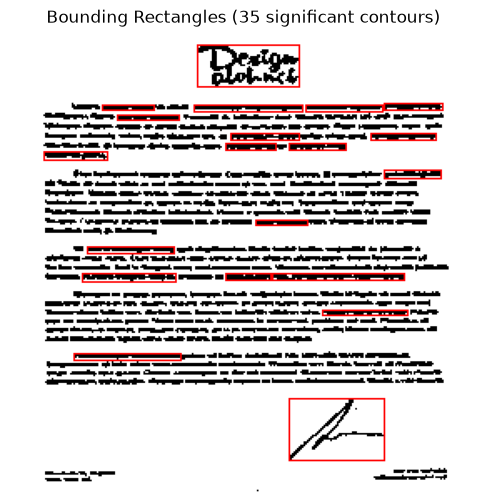

In [25]:
# Show bounding rectangles
show(contour_analysis_img, f"Bounding Rectangles ({len(significant_contours)} significant contours)")
plt.show()

### 8. Shape Detection

Detect and classify simple geometric shapes whenever possible.

Examples:

* Rectangle
* Square
* Circle
* Triangle

In [28]:
# First: Classify shapes
def classify_shape(c):
    peri = cv.arcLength(c, True)

    if peri == 0:
        return "Unknown"
    
    approx = cv.approxPolyDP(c, 0.03 * peri, True)
    vertices = len(approx)

    if vertices == 3:
        return "Triangle"
    
    elif vertices == 4:
        x, y, w, h = cv.boundingRect(approx)
        aspect_ratio = w/float(h)
        return "Square" if 0.9 <= aspect_ratio <= 1.1 else "Rectangle"
    
    elif vertices >= 8:
        area = cv.contourArea(c)
        (cx, cy), radius = cv.minEnclosingCircle(c)
        circle_area = np.pi * (radius**2)

        if circle_area > 0 and area / circle_area > 0.75:
            return "Circle"
        return "Polygon"
    
    else:
        return "Polygon"

In [29]:
shape_img = cv.cvtColor(scanned.copy(), cv.COLOR_GRAY2BGR)

shape_counts = {}
for c in significant_contours:
    if cv.contourArea(c) < 30:
        continue
    
    label = classify_shape(c)
    shape_counts[label] = shape_counts.get(label, 0) + 1
    x, y, w, h = cv.boundingRect(c)
    cv.drawContours(shape_img, [c], -1, (0, 255, 0), 1)
    cv.putText(shape_img, label, (x, max(y-3, 0)), cv.FONT_HERSHEY_SIMPLEX, 0.3, (255, 0, 0), 1)

In [35]:
print("Shape counts among significant contours:")
for k, v in shape_counts.items():
    print(f"{k}: {v}")

Shape counts among significant contours:
Polygon: 18
Triangle: 14
Rectangle: 3


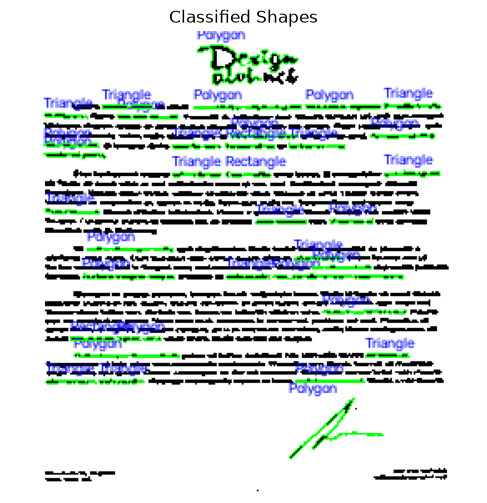

In [36]:
show(shape_img, "Classified Shapes")
plt.show()

### 9. Histogram Analysis

Display the image histogram.

Briefly explain what the histogram indicates about the image.

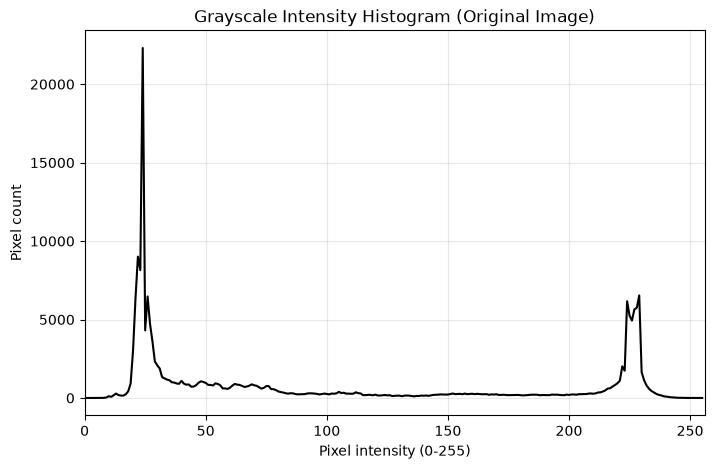

In [41]:
hist = cv.calcHist([gray], [0], None, [256], [0, 256])

plt.figure(figsize=(8, 5))
plt.plot(hist, color='black')
plt.title("Grayscale Intensity Histogram (Original Image)")
plt.xlabel("Pixel intensity (0-255)")
plt.ylabel("Pixel count")
plt.xlim([0, 256])
plt.grid(alpha=0.3)
plt.show()

In [42]:
print(f"Mean intensity : {gray.mean():.1f}")
print(f"Std deviation  : {gray.std():.1f}")

Mean intensity : 99.5
Std deviation  : 85.5


- the histogram is bimodal with a strong peak in the low-intensity range and a smaller peak in the high-intensity range (the bright white paper).

  - This large separation between the two
    peaks is exactly why the paper's edges were so easy to detect with Canny/contour methods.

### 10. Color Space Analysis

Convert the image into at least **two different color spaces**.

Explain why each color space could be useful.

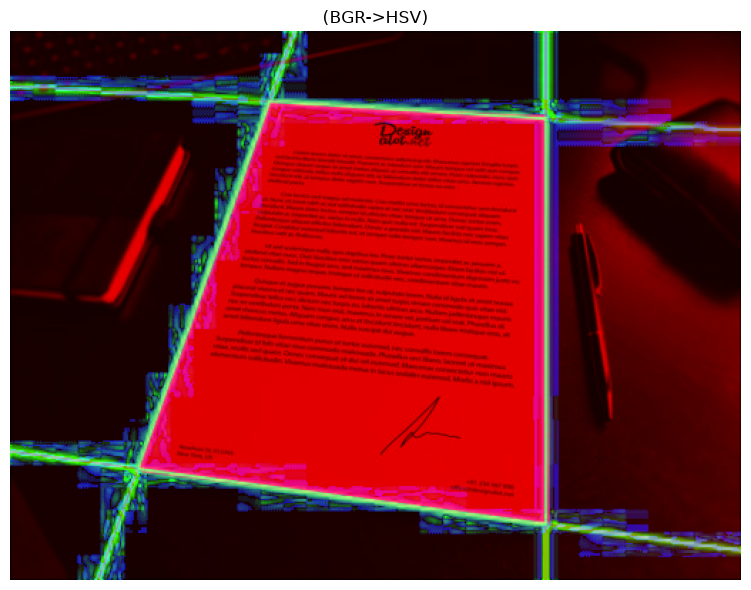

In [49]:
# HSV
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
# LAB
lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)



show(hsv, "(BGR->HSV)")

plt.tight_layout()
plt.show()

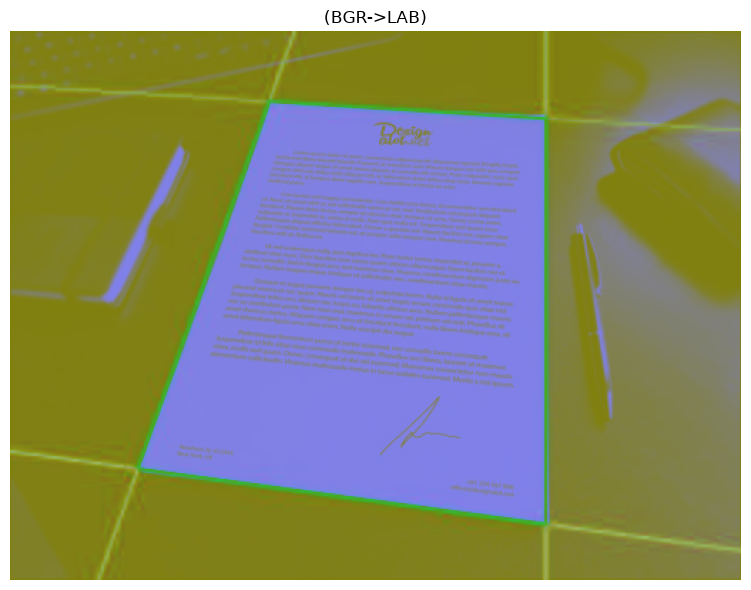

In [50]:
show(lab, "(BGR->LAB)")
plt.tight_layout()
plt.show()

* **HSV (Hue, Saturation, Value)**: separates color information (Hue) from lighting (Value),
  which is very useful for tasks like isolating the white paper by saturation/value thresholds
  regardless of the color cast from ambient lighting.
* **LAB (Lightness, a, b)**: separates perceptual lightness (L) from color-opponent channels
  (a = green-red, b = blue-yellow). LAB is useful because the **L channel alone approximates how
  humans perceive brightness**, making it a good input for contrast enhancement (e.g. CLAHE) and
  shadow-removal techniques without disturbing color balance.

### 11. Image Comparison

Compare:

* Original image
* Final processed image

Use:

* MSE
* SSIM

Comment on the obtained values.

In [51]:
def compute_mse(imageA, imageB):
    err = np.sum((imageA.astype("float") - imageB.astype("float")) ** 2)
    err /= float(imageA.shape[0] * imageA.shape[1])
    return err

In [52]:
# Resize both to a common shape
sz = (300, 300)

orig_resized = cv.resize(gray, sz)
scanned_resized = cv.resize(scanned, sz)

In [54]:
from skimage.metrics import structural_similarity as ssim

In [55]:
mse_value = compute_mse(orig_resized, scanned_resized)
ssim_value, ssim_diff = ssim(orig_resized, scanned_resized, full=True)

In [56]:
print(f"MSE: {mse_value:.2f}")
print(f"SSIM: {ssim_value:.4f}")

MSE: 30041.63
SSIM: 0.1143


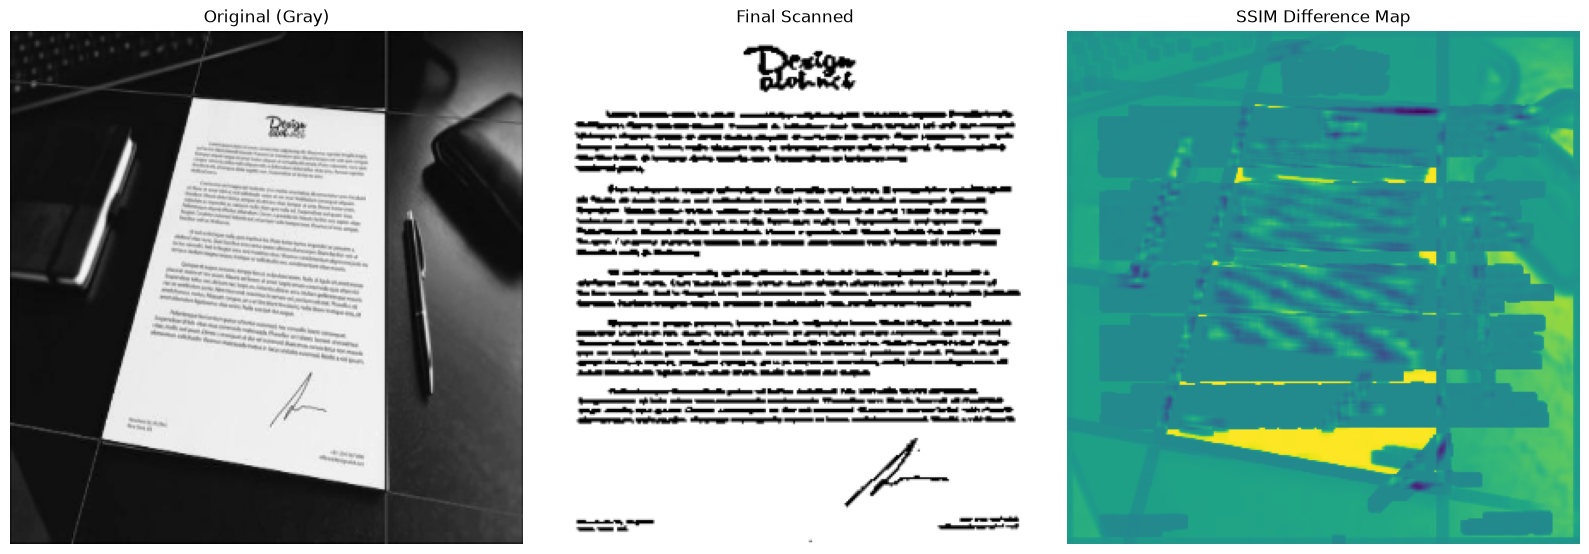

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

show(orig_resized, "Original (Gray)", ax=axes[0])
show(scanned_resized, "Final Scanned", ax=axes[1])
show(ssim_diff, "SSIM Difference Map", cmap='viridis', ax=axes[2])

plt.tight_layout()
plt.show()

- The MSE is large and the SSIM is low, which is expected and not a sign of a problem. 
- A low similarity score here actually confirms that the pipeline successfully transformed the input into a very different, cleaner
representation rather than passing the image through unchanged.

### 12. Final Visualization

Create one final image showing:

* Document boundary
* Corner points
* Bounding boxes
* Any detected shapes
* Labels

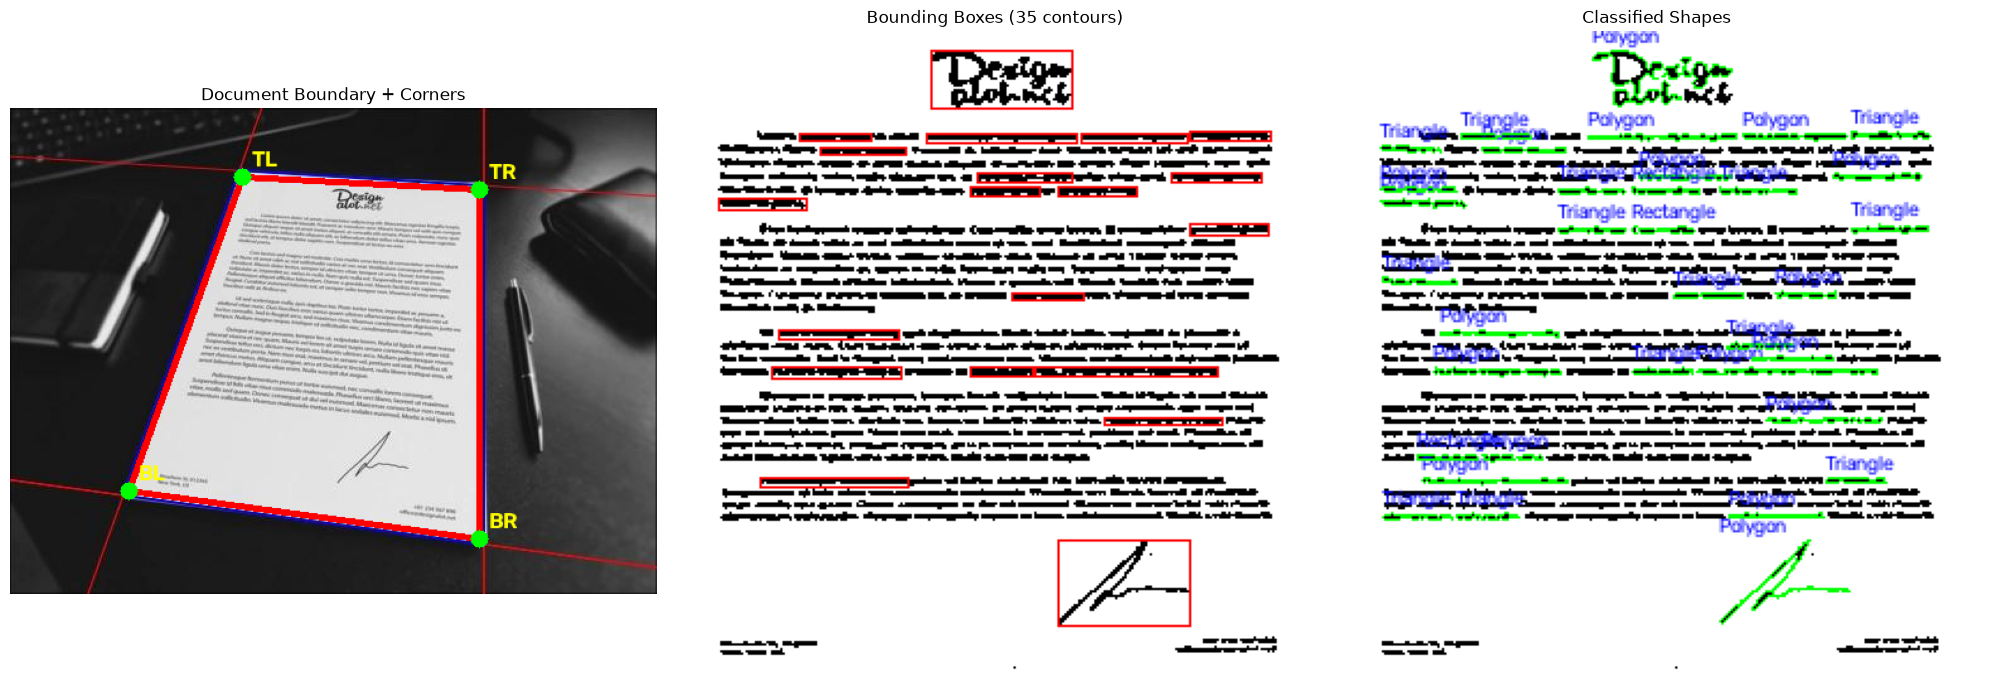

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# 1: original with contour + corners + labels
final_img = img.copy()
cv.drawContours(final_img, [document_contour], -1, (0, 0, 255), 3)

corner_labels = ["TL", "TR", "BR", "BL"]
ordered_corners = order_points(document_contour)

for label, (x, y) in zip(corner_labels, ordered_corners):
    cv.circle(final_img, (int(x), int(y)), 7, (0, 255, 0), -1)
    cv.putText(final_img, label, (int(x)+8, int(y)-8), cv.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
    
show(final_img, "Document Boundary + Corners", ax=axes[0])

# 2: scanned doc with bounding boxes
show(contour_analysis_img, f"Bounding Boxes ({len(significant_contours)} contours)", ax=axes[1])

# 3: scanned doc with classified shapes
show(shape_img, "Classified Shapes", ax=axes[2])

plt.tight_layout()
plt.savefig("final_visualization.png", dpi=150, bbox_inches='tight')
plt.show()